# 340 String MC effective area


## Common setup


### Zenith Direction Convention

The `zenith` column is the zenith angle `theta` of the sampled neutrino incoming/source direction, in radians. This follows the IceTray/LeptonInjector convention used by `EventProperties`: `zenith = 0` corresponds to a source overhead, with the neutrino propagating downward.

Therefore the angular-band plots use `cos(theta) = cos(zenith)`. The requested signed intervals `[-1, 1]` are interpreted as `cos(theta)` bands, not raw `theta` ranges.


### P-ONE Site Location for Future Declination Band Plots

For future declination-band studies, use the STRAW/P-ONE Cascadia Basin site location. The dark-site coordinates are given as `47°46' N, 127°46' W` in *STRAW: STRings for Absorption length in Water, Pathfinder for a neutrino telescope in the deep Pacific Ocean*. This corresponds to a detector latitude of `47.7667 deg` north.

The current notebook uses local `cos(theta)` bands, not true sky `sin(delta)` bands. A true declination conversion would also require the detector `+x/+y` orientation relative to geographic East/North.


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

REPO_ROOT = Path("/project/def-nahee/kbas/Graphnet-Applications")
DATA_DIR = REPO_ROOT / "Metadata/DatasetStatistics/TruthLevelStatistics"

plt.rcParams["figure.figsize"] = (7, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False


### Load weight files

The four String340MC weight files are loaded separately so flavor labels stay explicit throughout the notebook.


In [2]:
weight_files = {
    "electron": DATA_DIR / "Electron.csv",
    "muon": DATA_DIR / "Muon.csv",
    "nc": DATA_DIR / "NC.csv",
    "tau": DATA_DIR / "Tau.csv",
}

required_columns = {
    "pid", "totalEnergy", "zenith", "oneweight",
    "survivalProb", "final_weight",
    "triggered_nonoise_340_string", "triggered_nonoise_160_string",
    "triggered_nonoise_102_string",
}

def load_truth_statistics(path):
    if not path.exists():
        raise FileNotFoundError(f"Missing truth-statistics CSV: {path}")
    sample = pd.read_csv(path)
    missing = sorted(required_columns - set(sample.columns))
    if missing:
        raise ValueError(f"{path.name} is missing required columns: {missing}")
    # Keep all existing plotting helpers unchanged.
    sample["energy"] = sample["totalEnergy"]
    return sample

flavor_weights = {
    flavor: load_truth_statistics(path)
    for flavor, path in weight_files.items()
}

weight_files


{'electron': PosixPath('/project/def-nahee/kbas/Graphnet-Applications/Metadata/DatasetStatistics/TruthLevelStatistics/Electron.csv'),
 'muon': PosixPath('/project/def-nahee/kbas/Graphnet-Applications/Metadata/DatasetStatistics/TruthLevelStatistics/Muon.csv'),
 'nc': PosixPath('/project/def-nahee/kbas/Graphnet-Applications/Metadata/DatasetStatistics/TruthLevelStatistics/NC.csv'),
 'tau': PosixPath('/project/def-nahee/kbas/Graphnet-Applications/Metadata/DatasetStatistics/TruthLevelStatistics/Tau.csv')}

### Split pre-normalized weights

Each flavor is split into neutrino and antineutrino samples using numeric `pid`. The truth-statistics job has already written the fully scaled `oneweight`, `survivalProb`, and `final_weight`, so no notebook-level rescaling is applied.


In [3]:
def split_neutrino_samples(weights):
    return {
        "neutrino": weights.loc[weights["pid"] > 0].copy(),
        "antineutrino": weights.loc[weights["pid"] < 0].copy(),
    }


flavor_splits = {
    flavor: split_neutrino_samples(weights)
    for flavor, weights in flavor_weights.items()
}

weighted_flavor_splits = flavor_splits

# Convenient names for quick interactive inspection.
electron_neutrino = weighted_flavor_splits["electron"]["neutrino"]
electron_antineutrino = weighted_flavor_splits["electron"]["antineutrino"]
muon_neutrino = weighted_flavor_splits["muon"]["neutrino"]
muon_antineutrino = weighted_flavor_splits["muon"]["antineutrino"]
nc_neutrino = weighted_flavor_splits["nc"]["neutrino"]
nc_antineutrino = weighted_flavor_splits["nc"]["antineutrino"]
tau_neutrino = weighted_flavor_splits["tau"]["neutrino"]
tau_antineutrino = weighted_flavor_splits["tau"]["antineutrino"]


## Effective area and MC uncertainty

For each flavor, neutrino and antineutrino samples are binned in true energy. The plotted effective area is

$$
A_{\mathrm{eff}}(E) = \frac{\sum_{i \in E\,\mathrm{bin}} w_i}{\Delta E\,\Delta\Omega}.
$$

The MC uncertainty estimate is

$$
\sigma_{A_{\mathrm{eff}}}(E) = \frac{\sqrt{\sum_{i \in E\,\mathrm{bin}} w_i^2}}{\Delta E\,\Delta\Omega}.
$$

Here `w_i = final_weight_i`, and $\Delta\Omega = 4\pi$ for the all-sky average. Since `final_weight` has units of `GeV sr cm^2`, dividing by `Delta E` and `Delta Omega` first gives `cm^2`; the plotted values are converted to `m^2` by dividing by `1e4`.

Energy bins are built separately for each flavor from that flavor's generation-level energy range. This avoids the artificial high-energy edge effect that appeared when the muon energy range forced global bins beyond the electron, tau, and NC ranges.


In [4]:
flavor_plot_order = ["nc", "electron", "tau", "muon"]
flavor_colors = {
    "nc": "tab:gray",
    "electron": "tab:blue",
    "tau": "tab:green",
    "muon": "tab:orange",
}
flavor_display_labels = {
    "nc": r"NC",
    "electron": r"CC $\nu_e$",
    "tau": r"CC $\nu_\tau$",
    "muon": r"CC $\nu_\mu$",
}
particle_styles = {
    "neutrino": "-",
    "antineutrino": "--",
}
particle_display_labels = {
    "neutrino": r"$\nu$",
    "antineutrino": r"$\bar{\nu}$",
}
particle_colors = {
    "neutrino": "tab:blue",
    "antineutrino": "tab:orange",
}
solid_angle = 4 * np.pi
cm2_to_m2 = 1e-4


def make_flavor_energy_bins(samples, n_bins=30):
    energies = pd.concat(
        [sample.loc[sample["energy"] > 0, "energy"] for sample in samples.values()],
        ignore_index=True,
    )
    return np.logspace(np.log10(energies.min()), np.log10(energies.max()), n_bins)


flavor_energy_bins = {
    flavor: make_flavor_energy_bins(weighted_flavor_splits[flavor])
    for flavor in flavor_plot_order
}

trigger_column_by_geometry = {
    "340_string": "triggered_nonoise_340_string",
    "160_string": "triggered_nonoise_160_string",
    "102_string": "triggered_nonoise_102_string",
}


def make_triggered_weighted_flavor_splits(geometry_key):
    try:
        trigger_column = trigger_column_by_geometry[geometry_key]
    except KeyError as exc:
        raise ValueError(f"Unknown geometry key: {geometry_key}") from exc
    triggered_splits = {}

    for flavor in flavor_plot_order:
        triggered_splits[flavor] = {}

        for particle_type, sample in weighted_flavor_splits[flavor].items():
            triggered = pd.to_numeric(sample[trigger_column], errors="coerce").fillna(0) == 1
            triggered_splits[flavor][particle_type] = sample.loc[triggered].copy()

    return triggered_splits


def make_triggered_summary(triggered_splits):
    return pd.DataFrame(
        [
            {
                "flavor": flavor,
                "particle_type": particle_type,
                "n_generated": len(weighted_flavor_splits[flavor][particle_type]),
                "n_triggered": len(triggered_splits[flavor][particle_type]),
            }
            for flavor in triggered_splits
            for particle_type in triggered_splits[flavor]
        ]
    )

def available_flavors(sample_splits):
    return [flavor for flavor in flavor_plot_order if flavor in sample_splits]



def calculate_effective_area(sample, bins, weight_column="final_weight", solid_angle=4 * np.pi):
    plot_sample = sample.loc[(sample["energy"] > 0) & (sample[weight_column] > 0)]
    bin_widths = np.diff(bins)
    bin_centers = np.sqrt(bins[:-1] * bins[1:])

    weighted_sum, _ = np.histogram(
        plot_sample["energy"],
        bins=bins,
        weights=plot_sample[weight_column],
    )
    weighted_sum_sq, _ = np.histogram(
        plot_sample["energy"],
        bins=bins,
        weights=plot_sample[weight_column] ** 2,
    )

    norm = bin_widths * solid_angle
    effective_area_cm2 = weighted_sum / norm
    uncertainty_cm2 = np.sqrt(weighted_sum_sq) / norm
    effective_area = effective_area_cm2 * cm2_to_m2
    uncertainty = uncertainty_cm2 * cm2_to_m2
    return bin_centers, effective_area, uncertainty


def plot_area_curve(ax, centers, area, uncertainty, *, label, color, linestyle="-"):
    positive = area > 0
    x = centers[positive]
    y = area[positive]
    sigma = uncertainty[positive]
    lower = np.clip(y - sigma, 1e-300, None)
    upper = y + sigma

    ax.fill_between(
        x,
        lower,
        upper,
        color=color,
        alpha=0.12,
        linewidth=0,
        zorder=1,
    )
    ax.plot(
        x,
        lower,
        color=color,
        linestyle=":",
        linewidth=0.8,
        alpha=0.55,
        zorder=2,
    )
    ax.plot(
        x,
        upper,
        color=color,
        linestyle=":",
        linewidth=0.8,
        alpha=0.55,
        zorder=2,
    )
    ax.plot(
        x,
        y,
        color=color,
        linestyle=linestyle,
        linewidth=1.9,
        label=label,
        zorder=3,
    )


def style_effective_area_axes(fig, axes, title, ylabel=r"$A_{\mathrm{eff}}$ [m$^2$]"):
    for ax in axes:
        ax.set_xscale("log")
        ax.set_yscale("log")
        ax.grid(True, which="both", alpha=0.25)
        ax.legend(frameon=False)

    for ax in axes[2:]:
        ax.set_xlabel("True energy")
    for ax in axes[::2]:
        ax.set_ylabel(ylabel)

    fig.suptitle(title, y=1.02)
    fig.tight_layout()




def plot_weight_comparison_by_flavor(sample_splits, title):
    fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=False, sharey=False)
    axes = axes.ravel()
    for ax in axes:
        ax.tick_params(axis="y", labelleft=True)
    plot_flavors = available_flavors(sample_splits)
    weight_styles = {
        "oneweight": (":", "oneweight"),
        "final_weight": ("-", "oneweight * survivalProb"),
    }

    for ax, flavor in zip(axes, plot_flavors):
        bins = flavor_energy_bins[flavor]

        for particle_type, color in particle_colors.items():
            for weight_column, (linestyle, weight_label) in weight_styles.items():
                centers, area, uncertainty = calculate_effective_area(
                    sample_splits[flavor][particle_type],
                    bins,
                    weight_column=weight_column,
                )
                plot_area_curve(
                    ax,
                    centers,
                    area,
                    uncertainty,
                    label=f"{particle_display_labels[particle_type]} {weight_label}",
                    color=color,
                    linestyle=linestyle,
                )

        ax.set_title(flavor_display_labels[flavor])

    for ax in axes[len(plot_flavors):]:
        ax.set_visible(False)

    style_effective_area_axes(fig, axes[:len(plot_flavors)], title)
    plt.show()

cos_theta_bands = [
    (0.6, 1.0),
    (0.2, 0.6),
    (-0.2, 0.2),
    (-0.6, -0.2),
    (-1.0, -0.6),
]
cos_theta_band_colors = ["tab:blue", "tab:orange", "tab:green", "tab:red", "tab:purple"]
cos_theta_weight_styles = {
    "oneweight": (":", "oneweight"),
    "final_weight": ("-", "oneweight * survivalProb"),
}


def add_cos_theta(sample):
    sample = sample.copy()
    sample["cos_theta"] = np.cos(sample["zenith"])
    return sample


def select_cos_theta_band(sample, low, high):
    if high == 1.0:
        return sample.loc[
            (sample["cos_theta"] >= low)
            & (sample["cos_theta"] <= high)
        ]
    return sample.loc[
        (sample["cos_theta"] >= low)
        & (sample["cos_theta"] < high)
    ]


def plot_effective_area_by_cos_theta(sample_splits, title):
    fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=False, sharey=False)
    axes = axes.ravel()
    for ax in axes:
        ax.tick_params(axis="y", labelleft=True)
    plot_flavors = available_flavors(sample_splits)

    for ax, flavor in zip(axes, plot_flavors):
        bins = flavor_energy_bins[flavor]
        flavor_sample = pd.concat(
            [
                sample_splits[flavor]["neutrino"],
                sample_splits[flavor]["antineutrino"],
            ],
            ignore_index=True,
        )
        flavor_sample = add_cos_theta(flavor_sample)

        for (low, high), color in zip(cos_theta_bands, cos_theta_band_colors):
            band_sample = select_cos_theta_band(flavor_sample, low, high)
            for weight_column, (linestyle, weight_label) in cos_theta_weight_styles.items():
                centers, area, uncertainty = calculate_effective_area(
                    band_sample,
                    bins,
                    weight_column=weight_column,
                )
                positive = area > 0
                ax.plot(
                    centers[positive],
                    area[positive],
                    color=color,
                    linestyle=linestyle,
                    linewidth=1.9,
                    label=f"({low:.1f}, {high:.1f}] {weight_label}",
                )

        ax.set_title(flavor_display_labels[flavor])
        ax.set_xscale("log")
        ax.set_yscale("log")
        ax.grid(True, which="both", alpha=0.25)
        ax.legend(title=r"$\cos\theta$", frameon=False, fontsize=8)

    for ax in axes[len(plot_flavors):]:
        ax.set_visible(False)

    visible_axes = axes[:len(plot_flavors)]
    for ax in visible_axes[2:]:
        ax.set_xlabel("True energy")
    for ax in visible_axes[::2]:
        ax.set_ylabel(r"$A_{\mathrm{eff},\nu+\bar{\nu}}$ [m$^2$]")

    fig.suptitle(title, y=1.02)
    fig.tight_layout()
    plt.show()

comparison_colors = {
    "Generation level": "tab:gray",
    "340 String": "tab:blue",
    "160 String": "tab:green",
    "102 String": "tab:purple",
}
comparison_weight_styles = {
    "oneweight": (":", "oneweight"),
    "final_weight": ("-", "oneweight * survivalProb"),
}


def concat_samples_for_flavor(sample_splits, flavor):
    parts = []
    if flavor not in sample_splits:
        return pd.DataFrame()
    for particle_type in ["neutrino", "antineutrino"]:
        if particle_type in sample_splits[flavor]:
            parts.append(sample_splits[flavor][particle_type])
    if not parts:
        return pd.DataFrame()
    return pd.concat(parts, ignore_index=True)


def concat_all_flavors(sample_splits):
    parts = [
        concat_samples_for_flavor(sample_splits, flavor)
        for flavor in flavor_plot_order
        if flavor in sample_splits
    ]
    parts = [part for part in parts if not part.empty]
    if not parts:
        return pd.DataFrame()
    return pd.concat(parts, ignore_index=True)


def make_energy_bins_from_sample(sample, n_bins=30):
    energies = sample.loc[sample["energy"] > 0, "energy"]
    return np.logspace(np.log10(energies.min()), np.log10(energies.max()), n_bins)


def plot_mixed_total_comparison(comparison_splits, title):
    total_samples = {
        name: concat_all_flavors(sample_splits)
        for name, sample_splits in comparison_splits.items()
    }
    total_samples = {
        name: sample
        for name, sample in total_samples.items()
        if not sample.empty
    }
    reference_sample = pd.concat(total_samples.values(), ignore_index=True)
    bins = make_energy_bins_from_sample(reference_sample)

    fig, ax = plt.subplots(figsize=(8, 5.5))

    for name, sample in total_samples.items():
        color = comparison_colors[name]
        for weight_column, (linestyle, weight_label) in comparison_weight_styles.items():
            centers, area, uncertainty = calculate_effective_area(
                sample,
                bins,
                weight_column=weight_column,
            )
            plot_area_curve(
                ax,
                centers,
                area,
                uncertainty,
                label=f"{name} {weight_label}",
                color=color,
                linestyle=linestyle,
            )

    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel("True energy")
    ax.set_ylabel(r"$A_{\mathrm{eff},\nu+\bar{\nu}}$ [m$^2$]")
    ax.grid(True, which="both", alpha=0.25)
    ax.legend(frameon=False, fontsize=8)
    ax.set_title(title)
    fig.tight_layout()
    plt.show()


def plot_mixed_flavor_comparison(comparison_splits, title):
    fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=False, sharey=False)
    axes = axes.ravel()
    for ax in axes:
        ax.tick_params(axis="y", labelleft=True)

    for ax, flavor in zip(axes, flavor_plot_order):
        samples = {
            name: concat_samples_for_flavor(sample_splits, flavor)
            for name, sample_splits in comparison_splits.items()
            if flavor in sample_splits
        }
        samples = {
            name: sample
            for name, sample in samples.items()
            if not sample.empty
        }
        if not samples:
            ax.set_visible(False)
            continue

        reference_sample = pd.concat(samples.values(), ignore_index=True)
        bins = make_energy_bins_from_sample(reference_sample)

        for name, sample in samples.items():
            color = comparison_colors[name]
            for weight_column, (linestyle, weight_label) in comparison_weight_styles.items():
                centers, area, uncertainty = calculate_effective_area(
                    sample,
                    bins,
                    weight_column=weight_column,
                )
                plot_area_curve(
                    ax,
                    centers,
                    area,
                    uncertainty,
                    label=f"{name} {weight_label}",
                    color=color,
                    linestyle=linestyle,
                )

        ax.set_title(flavor_display_labels[flavor])
        ax.set_xscale("log")
        ax.set_yscale("log")
        ax.grid(True, which="both", alpha=0.25)
        ax.legend(frameon=False, fontsize=7)

    for ax in axes[2:]:
        if ax.get_visible():
            ax.set_xlabel("True energy")
    for ax in axes[::2]:
        if ax.get_visible():
            ax.set_ylabel(r"$A_{\mathrm{eff},\nu+\bar{\nu}}$ [m$^2$]")

    fig.suptitle(title, y=1.02)
    fig.tight_layout()
    plt.show()


def combined_sample_effective_area(sample_splits, flavor, bins, weight_column="final_weight"):
    sample = concat_samples_for_flavor(sample_splits, flavor)
    if sample.empty:
        return None, None, None
    return calculate_effective_area(sample, bins, weight_column=weight_column)


def figure_of_merit_from_area(area, area_uncertainty, sigma_rad):
    sigma = np.asarray(sigma_rad, dtype=float)
    if sigma.ndim == 0:
        sigma = np.full_like(area, float(sigma), dtype=float)

    weight = area / (4 * np.pi * sigma**2)
    weight_uncertainty = area_uncertainty / (4 * np.pi * sigma**2)

    fom = np.full_like(area, np.nan, dtype=float)
    fom_uncertainty = np.full_like(area, np.nan, dtype=float)
    positive = weight > 0
    fom[positive] = np.sqrt(weight[positive])
    fom_uncertainty[positive] = weight_uncertainty[positive] / (2 * fom[positive])
    return fom, fom_uncertainty


def plot_figure_of_merit_by_flavor(comparison_splits, angular_resolution_deg, title, weight_column="final_weight"):
    fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=False, sharey=False)
    axes = axes.ravel()
    for ax in axes:
        ax.tick_params(axis="y", labelleft=True)

    for ax, flavor in zip(axes, flavor_plot_order):
        flavor_samples = [
            concat_samples_for_flavor(sample_splits, flavor)
            for sample_splits in comparison_splits.values()
            if flavor in sample_splits
        ]
        flavor_samples = [sample for sample in flavor_samples if not sample.empty]
        if not flavor_samples:
            ax.set_visible(False)
            continue

        bins = make_energy_bins_from_sample(pd.concat(flavor_samples, ignore_index=True))

        for name, sample_splits in comparison_splits.items():
            if flavor not in sample_splits:
                continue
            centers, area, area_uncertainty = combined_sample_effective_area(
                sample_splits,
                flavor,
                bins,
                weight_column=weight_column,
            )
            if centers is None:
                continue

            sigma_deg = angular_resolution_deg[name][flavor]
            fom, fom_uncertainty = figure_of_merit_from_area(
                area,
                area_uncertainty,
                np.deg2rad(sigma_deg),
            )
            plot_area_curve(
                ax,
                centers,
                fom,
                fom_uncertainty,
                label=f"{name} ({sigma_deg:g} deg)",
                color=comparison_colors[name],
            )

        ax.set_title(flavor_display_labels[flavor])
        ax.set_xscale("log")
        ax.set_yscale("log")
        ax.grid(True, which="both", alpha=0.25)
        ax.legend(frameon=False, fontsize=8)

    for ax in axes[2:]:
        if ax.get_visible():
            ax.set_xlabel("True energy")
    for ax in axes[::2]:
        if ax.get_visible():
            ax.set_ylabel("FoM")

    fig.suptitle(title, y=1.02)
    fig.tight_layout()
    plt.show()


## Generation Level

All generated MC events are used here. Each flavor panel compares neutrino and antineutrino curves with `oneweight` alone and with `oneweight * survivalProb`.


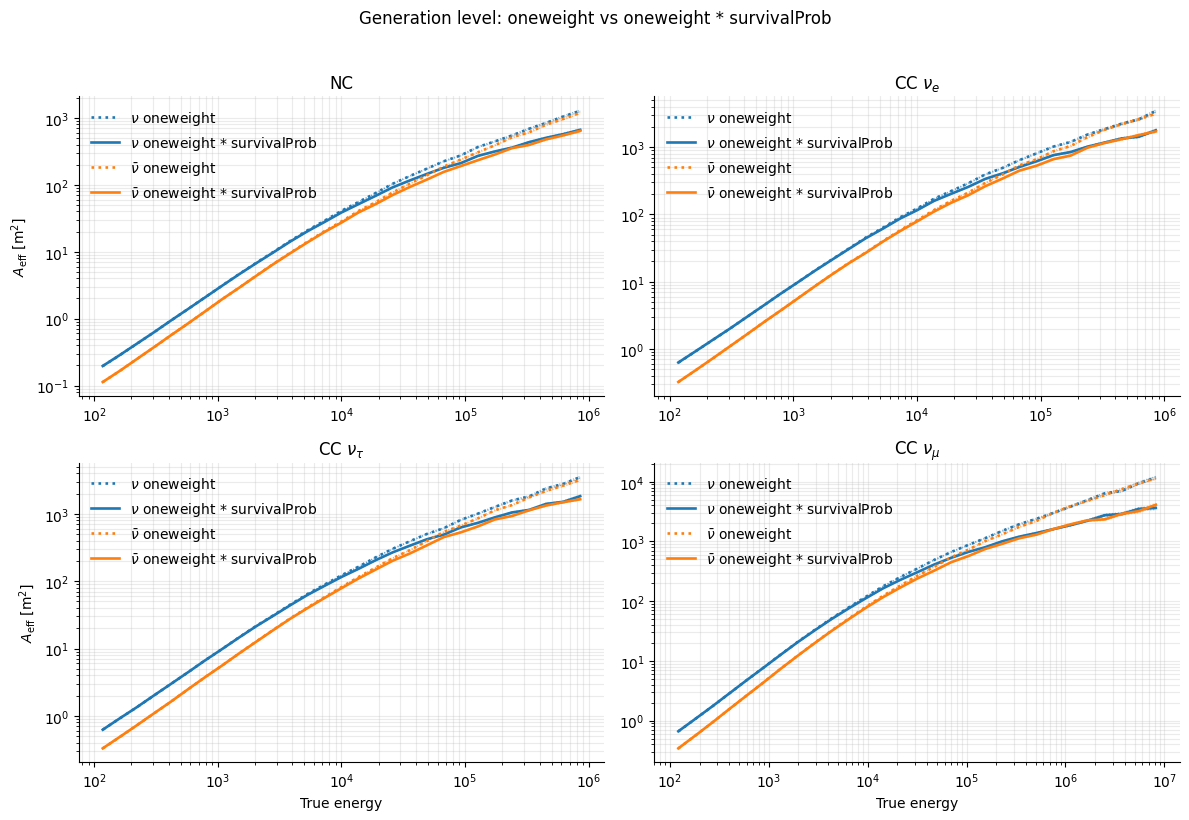

In [5]:
plot_weight_comparison_by_flavor(
    weighted_flavor_splits,
    "Generation level: oneweight vs oneweight * survivalProb",
)


### Generation-level effective area by cos(theta) band

All generated events are grouped by `cos(theta) = cos(zenith)`. For each angular band, the plot shows both `oneweight` and `oneweight * survivalProb`.


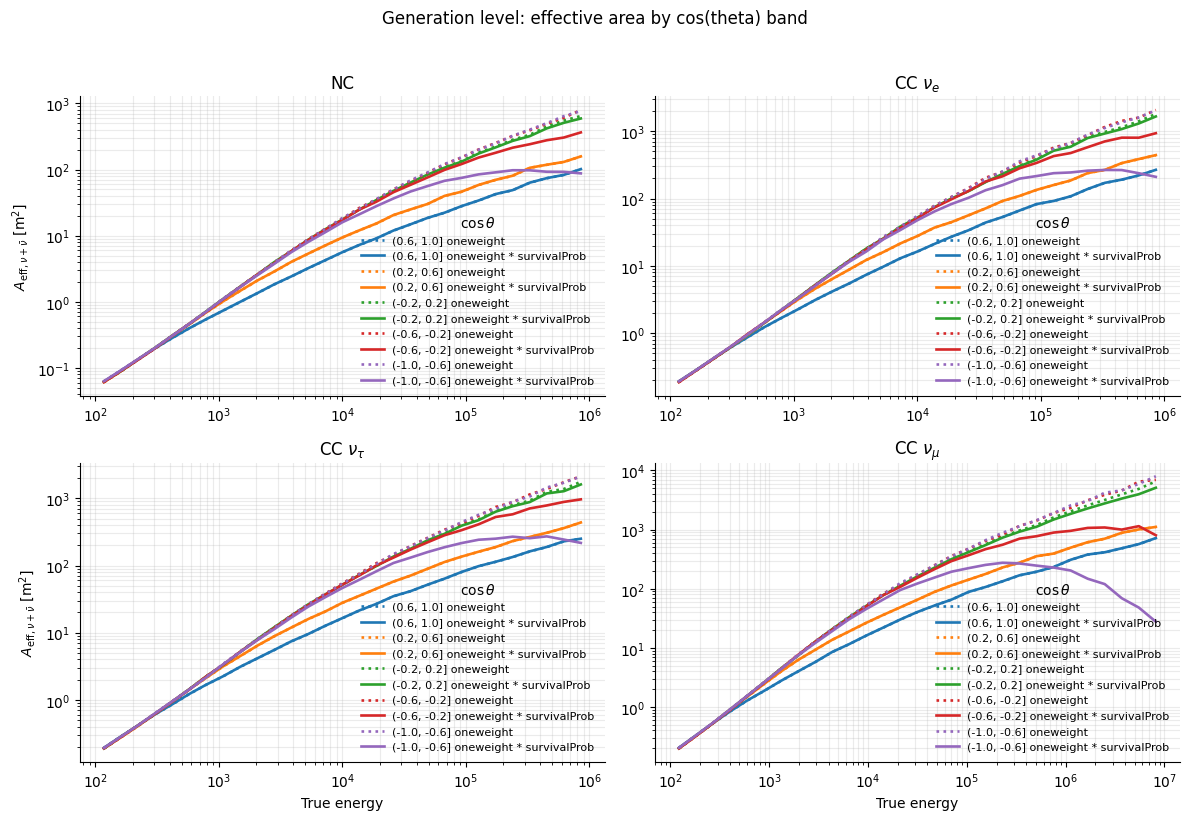

In [6]:
plot_effective_area_by_cos_theta(
    weighted_flavor_splits,
    "Generation level: effective area by cos(theta) band",
)


## 340 String

Triggered events are selected directly from each truth-statistics CSV using `triggered_nonoise_340_string`.


In [7]:
triggered_weighted_flavor_splits_340_string = make_triggered_weighted_flavor_splits("340_string")


In [8]:
triggered_summary_340_string = make_triggered_summary(triggered_weighted_flavor_splits_340_string)
triggered_summary_340_string


,flavor,particle_type,n_generated,n_triggered
0,nc,neutrino,998786,98425
1,nc,antineutrino,999483,90434
2,electron,neutrino,686609,84871
3,electron,antineutrino,684900,85132
4,tau,neutrino,997251,124888
5,tau,antineutrino,995304,124928
6,muon,neutrino,975991,213126
7,muon,antineutrino,964338,210978


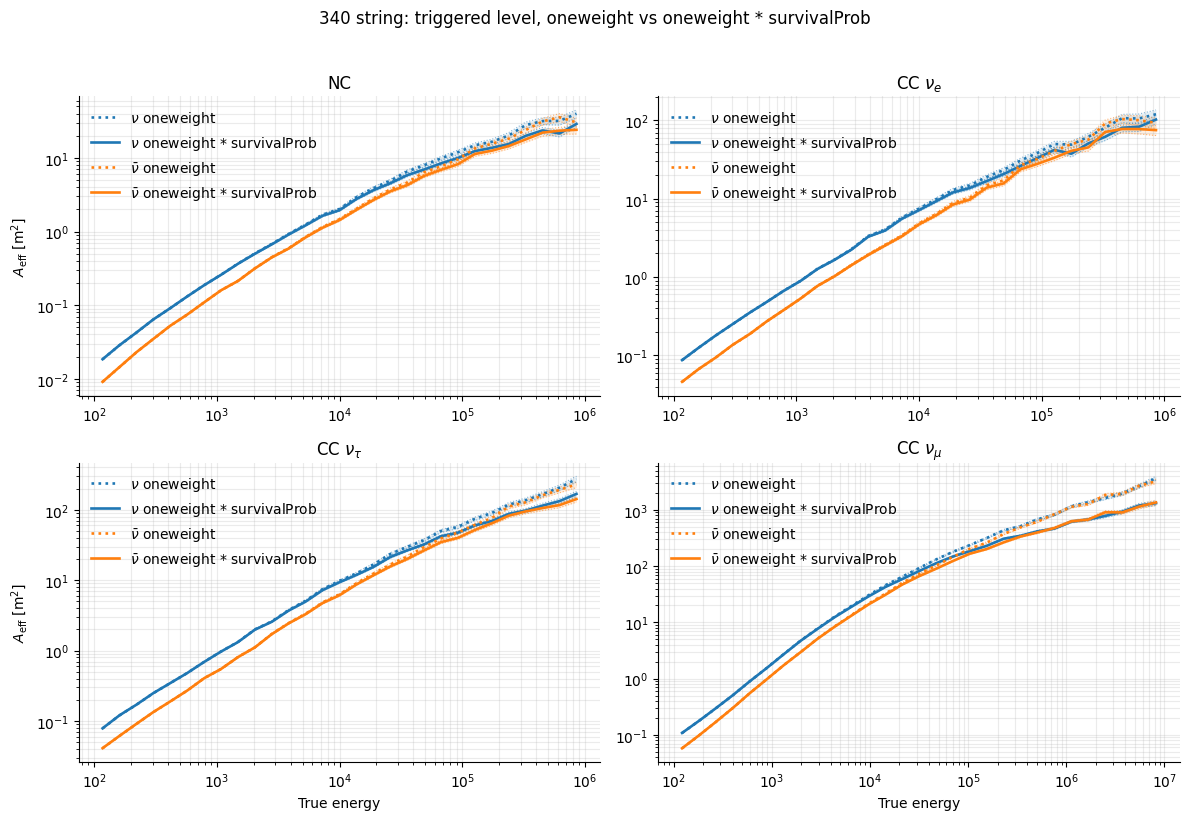

In [9]:
plot_weight_comparison_by_flavor(
    triggered_weighted_flavor_splits_340_string,
    "340 string: triggered level, oneweight vs oneweight * survivalProb",
)


### Triggered effective area by cos(theta) band - 340 String

The bands use `cos(theta) = cos(zenith)`, where `theta` is the zenith angle of the opposite direction.


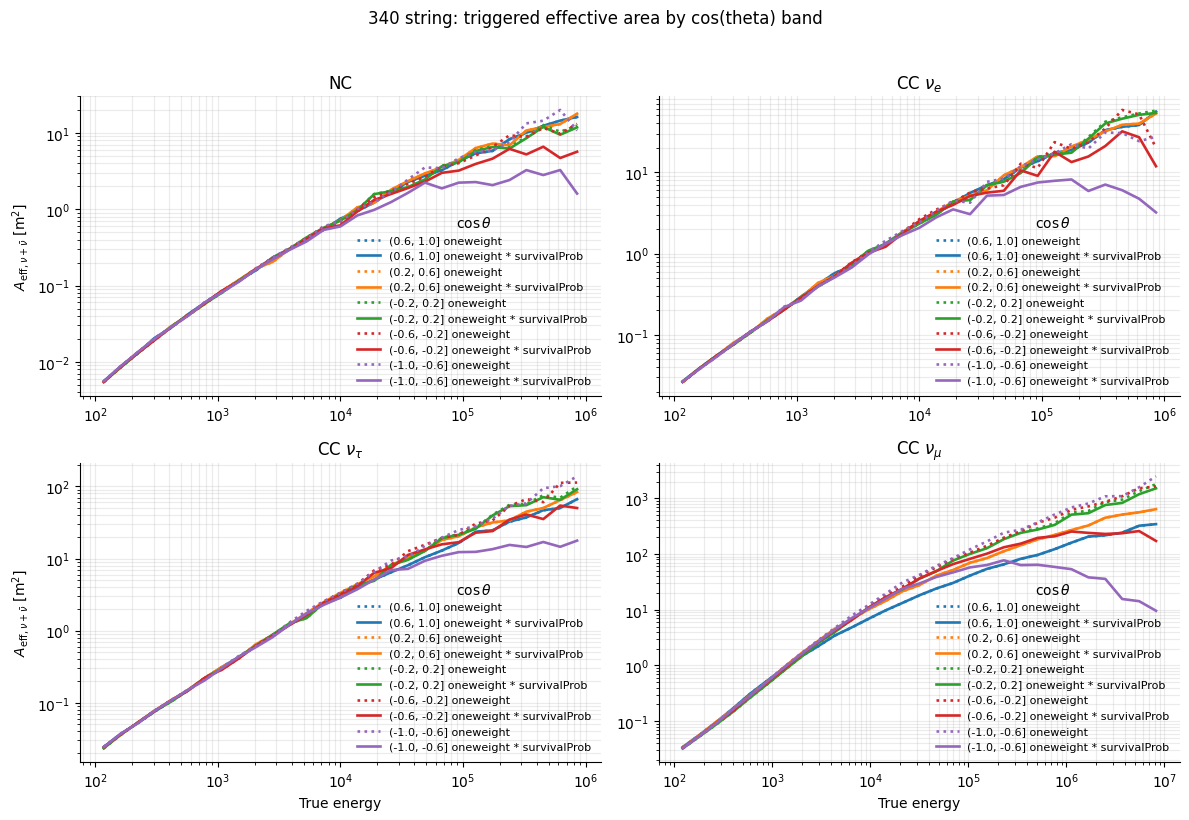

In [10]:
plot_effective_area_by_cos_theta(
    triggered_weighted_flavor_splits_340_string,
    "340 string: triggered effective area by cos(theta) band",
)


## 160 String

Triggered events are selected directly from each truth-statistics CSV using `triggered_nonoise_160_string`.


In [11]:
triggered_weighted_flavor_splits_160_string = make_triggered_weighted_flavor_splits("160_string")


In [12]:
triggered_summary_160_string = make_triggered_summary(triggered_weighted_flavor_splits_160_string)
triggered_summary_160_string


,flavor,particle_type,n_generated,n_triggered
0,nc,neutrino,998786,47678
1,nc,antineutrino,999483,43580
2,electron,neutrino,686609,41876
3,electron,antineutrino,684900,41608
4,tau,neutrino,997251,62458
5,tau,antineutrino,995304,62744
6,muon,neutrino,975991,119272
7,muon,antineutrino,964338,117850


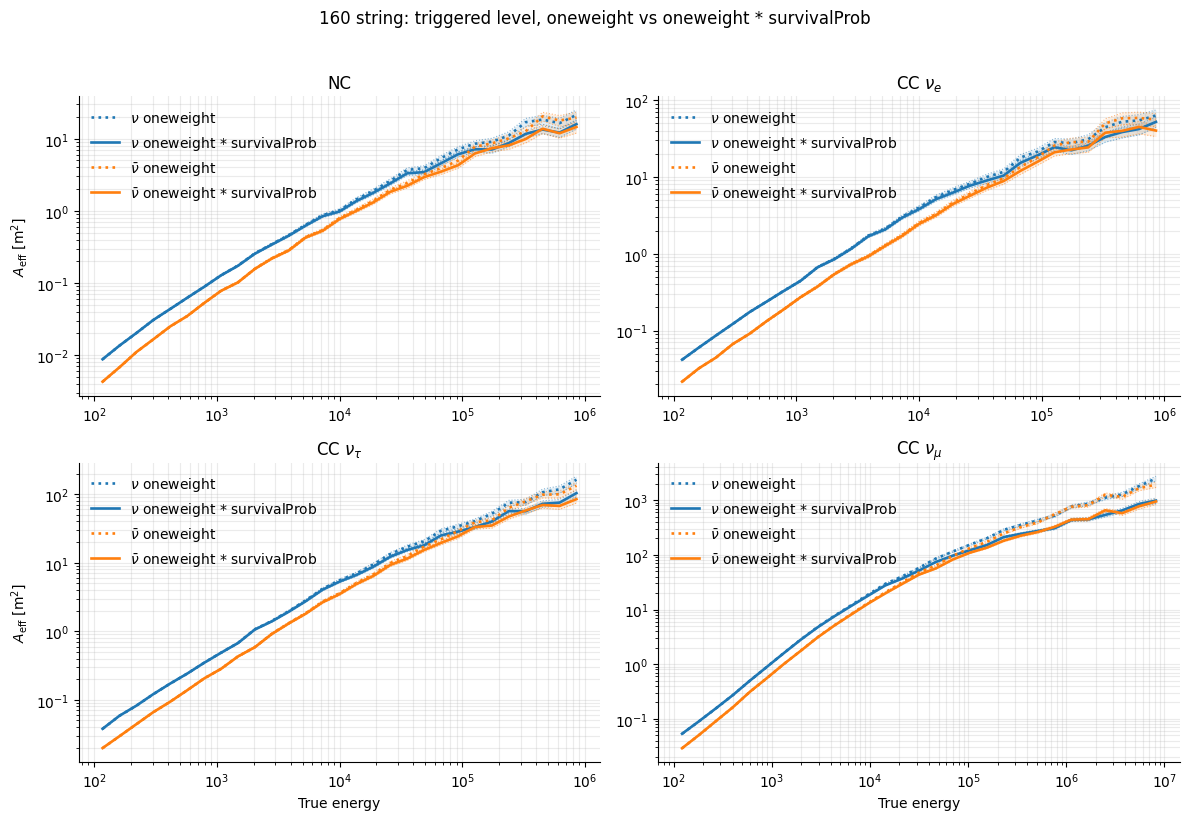

In [13]:
plot_weight_comparison_by_flavor(
    triggered_weighted_flavor_splits_160_string,
    "160 string: triggered level, oneweight vs oneweight * survivalProb",
)


### Triggered effective area by cos(theta) band - 160 String

The bands use `cos(theta) = cos(zenith)`, where `theta` is the zenith angle of the opposite direction.


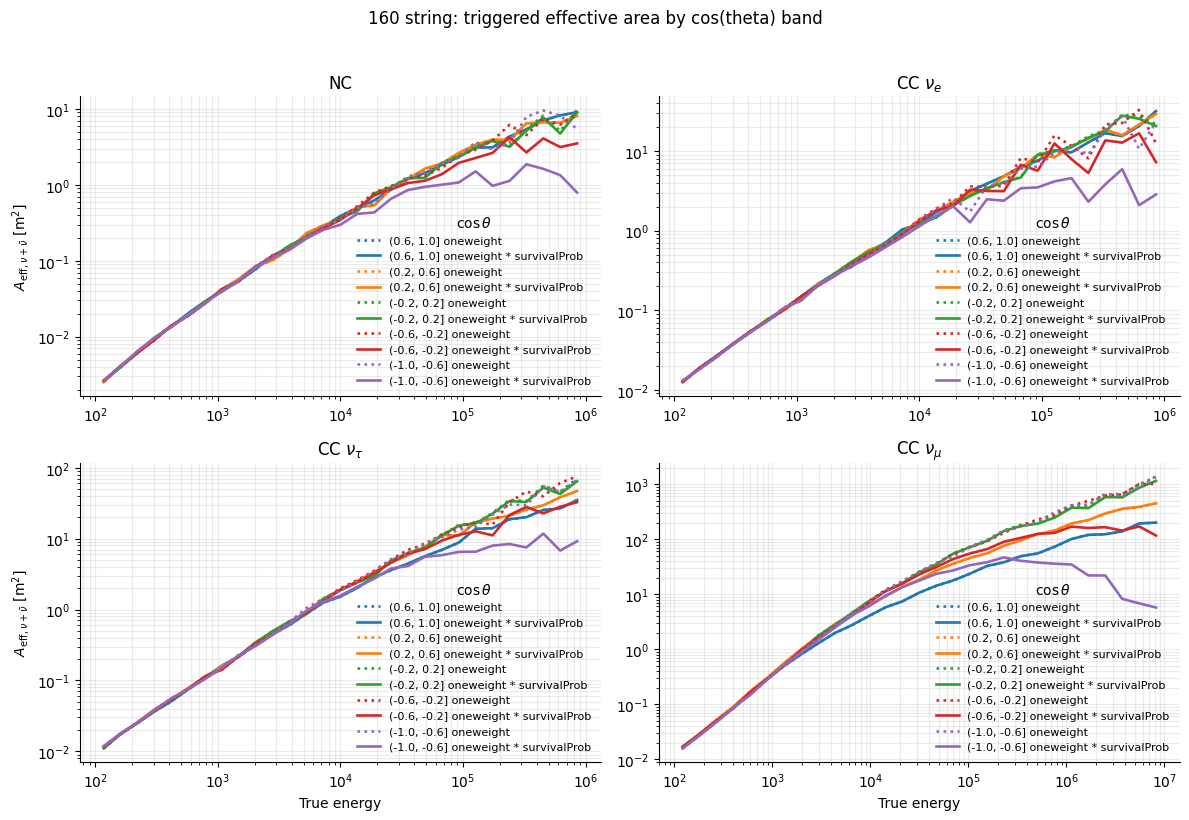

In [14]:
plot_effective_area_by_cos_theta(
    triggered_weighted_flavor_splits_160_string,
    "160 string: triggered effective area by cos(theta) band",
)


## 102 String

Triggered events are selected directly from each truth-statistics CSV using `triggered_nonoise_102_string`.


In [15]:
triggered_weighted_flavor_splits_102_string = make_triggered_weighted_flavor_splits("102_string")


In [16]:
triggered_summary_102_string = make_triggered_summary(triggered_weighted_flavor_splits_102_string)
triggered_summary_102_string


,flavor,particle_type,n_generated,n_triggered
0,nc,neutrino,998786,34214
1,nc,antineutrino,999483,31123
2,electron,neutrino,686609,31813
3,electron,antineutrino,684900,31710
4,tau,neutrino,997251,47643
5,tau,antineutrino,995304,47804
6,muon,neutrino,975991,104723
7,muon,antineutrino,964338,103746


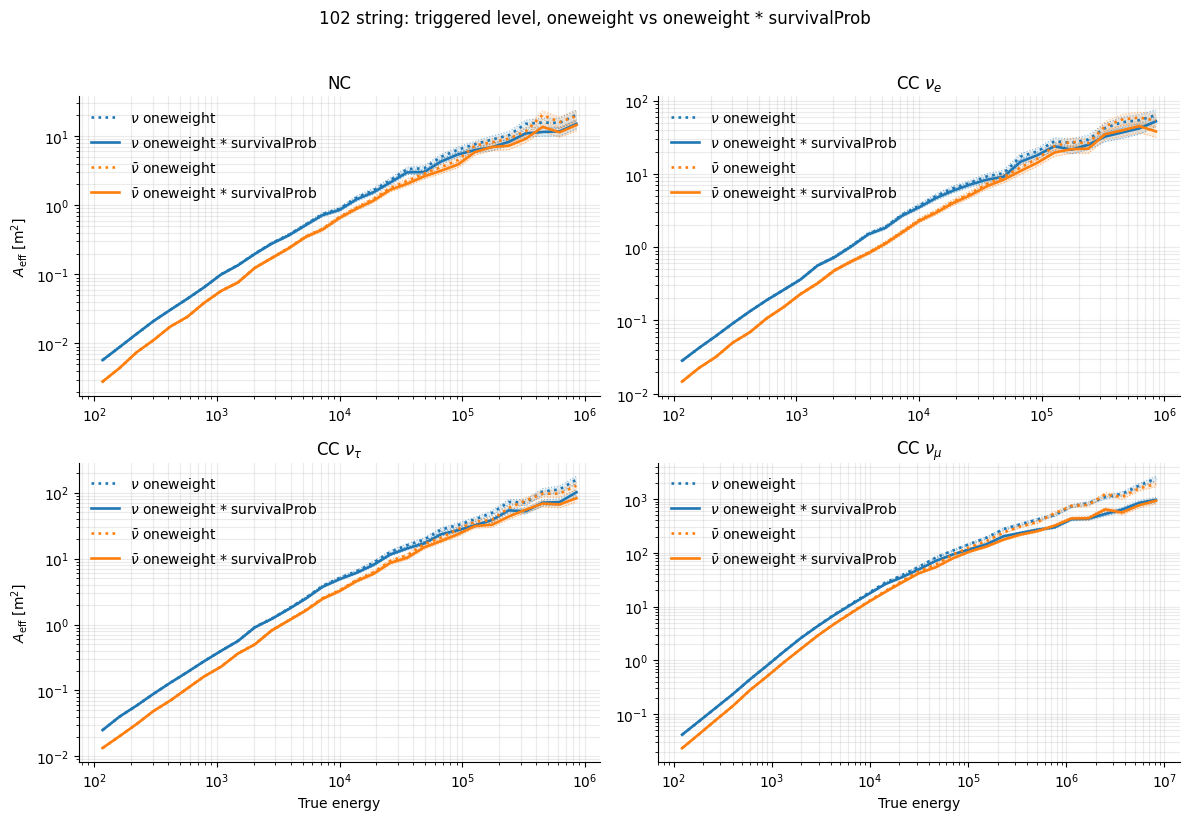

In [17]:
plot_weight_comparison_by_flavor(
    triggered_weighted_flavor_splits_102_string,
    "102 string: triggered level, oneweight vs oneweight * survivalProb",
)


### Triggered effective area by cos(theta) band - 102 String

The bands use `cos(theta) = cos(zenith)`, where `theta` is the zenith angle of the opposite direction.


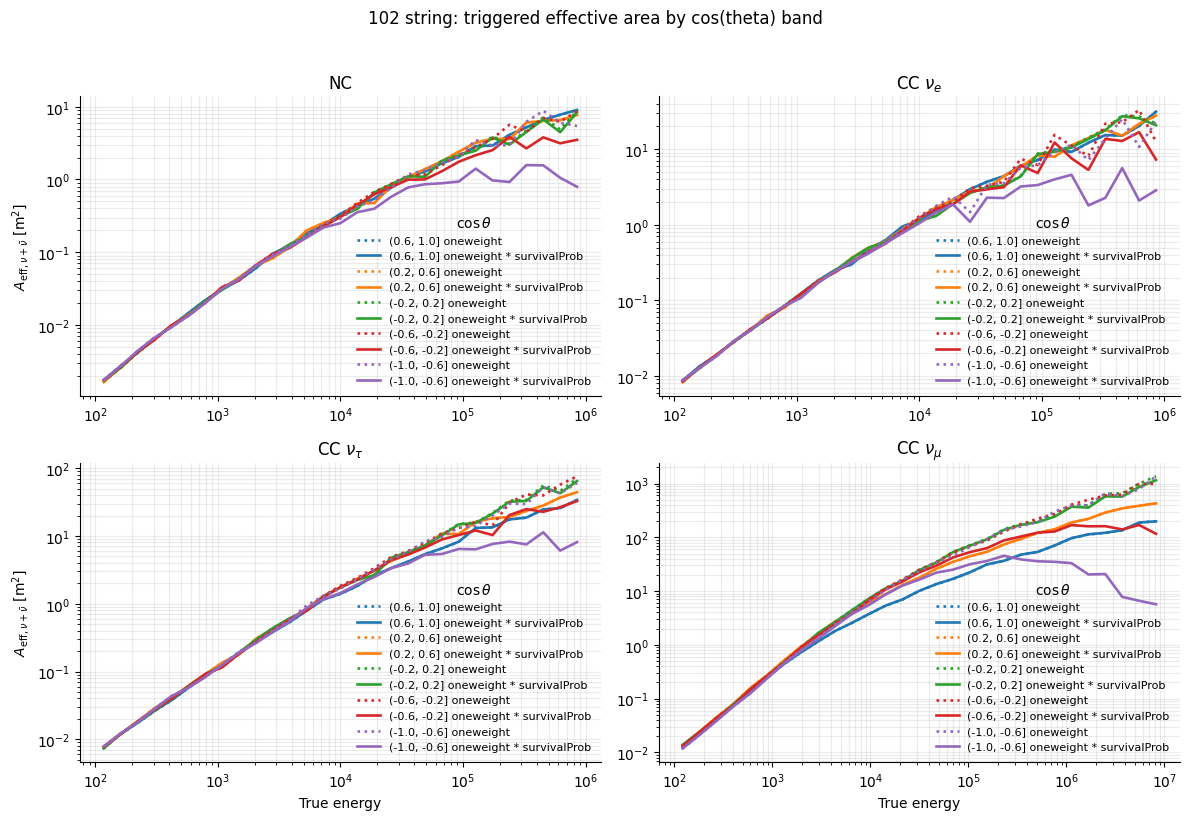

In [18]:
plot_effective_area_by_cos_theta(
    triggered_weighted_flavor_splits_102_string,
    "102 string: triggered effective area by cos(theta) band",
)


## Mixed Comparison Plots

These plots compare the mixed all-flavor effective area across Generation Level, 340 String, 160 String, and 102 String. For each sample, dotted curves use `oneweight`; solid curves use `oneweight * survivalProb`.


In [19]:
mixed_comparison_splits = {
    "Generation level": weighted_flavor_splits,
    "340 String": triggered_weighted_flavor_splits_340_string,
    "160 String": triggered_weighted_flavor_splits_160_string,
    "102 String": triggered_weighted_flavor_splits_102_string,
}


### All-flavor total comparison

All flavors and both neutrino/antineutrino samples are summed together.


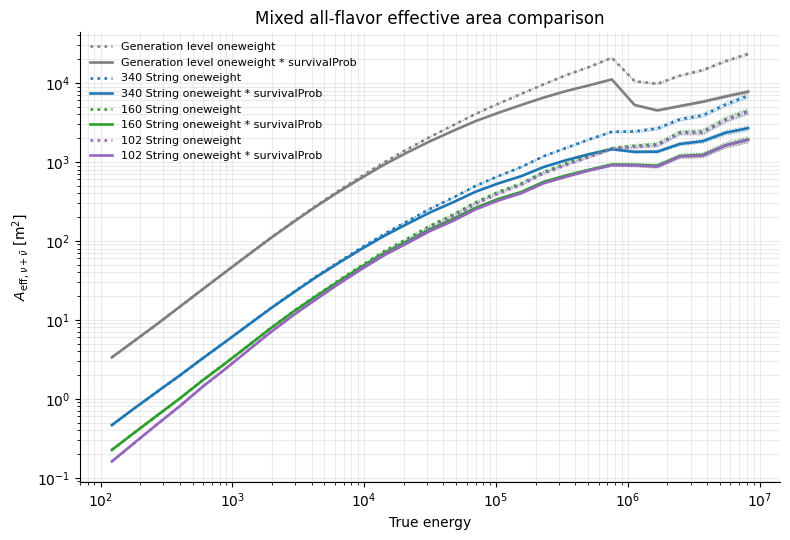

In [20]:
plot_mixed_total_comparison(
    mixed_comparison_splits,
    "Mixed all-flavor effective area comparison",
)


### Flavor-separated comparison

Each panel sums neutrino and antineutrino within one flavor.


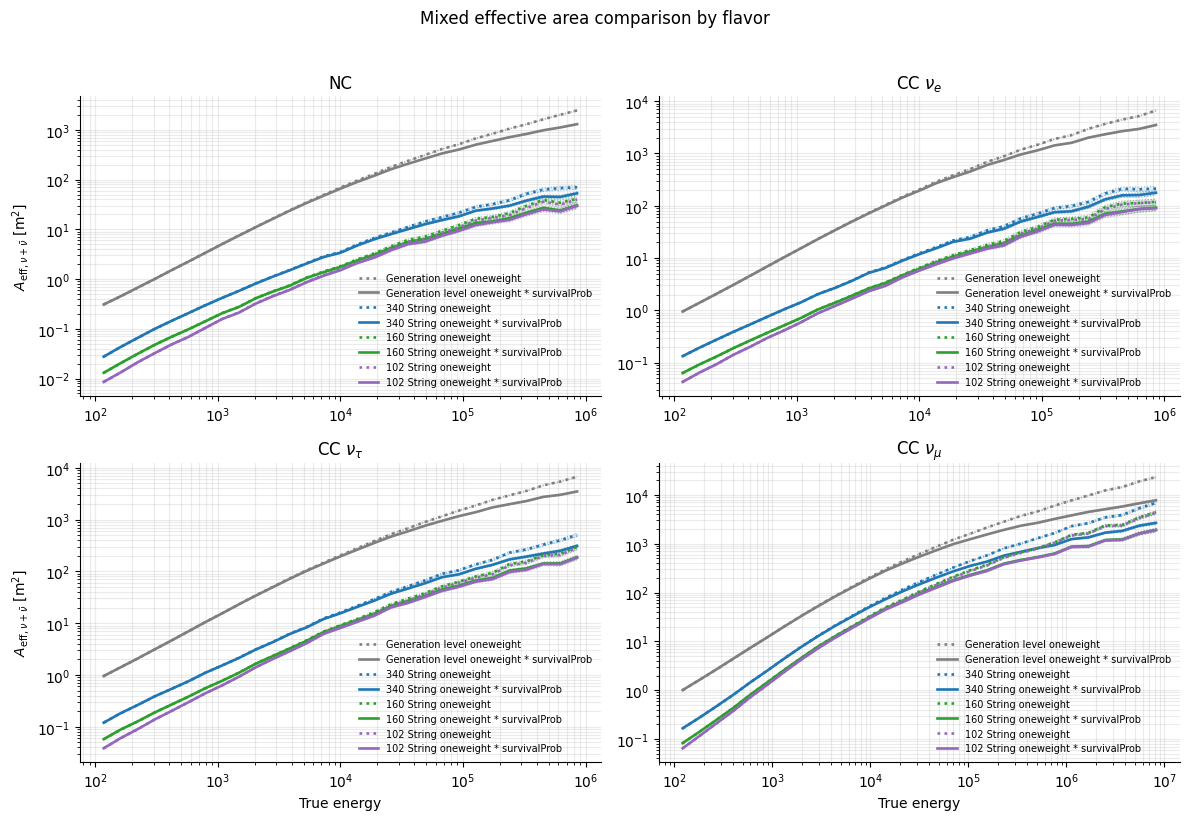

In [21]:
plot_mixed_flavor_comparison(
    mixed_comparison_splits,
    "Mixed effective area comparison by flavor",
)


## Figure of Merit

The figure of merit combines effective area and angular resolution per energy bin:

$$
\mathrm{FoM}(E) = \sqrt{\frac{A_{\mathrm{eff}}(E)}{4\pi\,\sigma(E)^2}}
$$

The current event tables do not contain an angular-resolution estimate, so the next cell keeps the angular resolution as an editable input. I should these placeholder values with the per-flavor/per-geometry angular resolution when available.


In [22]:
angular_resolution_deg = {
    geometry: {flavor: 1.0 for flavor in flavor_plot_order}
    for geometry in mixed_comparison_splits
}

angular_resolution_deg


{'Generation level': {'nc': 1.0, 'electron': 1.0, 'tau': 1.0, 'muon': 1.0},
 '340 String': {'nc': 1.0, 'electron': 1.0, 'tau': 1.0, 'muon': 1.0},
 '160 String': {'nc': 1.0, 'electron': 1.0, 'tau': 1.0, 'muon': 1.0},
 '102 String': {'nc': 1.0, 'electron': 1.0, 'tau': 1.0, 'muon': 1.0}}

In [23]:
# plot_figure_of_merit_by_flavor(
#     mixed_comparison_splits,
#     angular_resolution_deg,
#     "Figure of merit by flavor",
#     weight_column="final_weight",
# )
